In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Paired')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.titleweight'] = 'bold'

print('All libraries loaded successfully!')

All libraries loaded successfully!


In [4]:
players = [
    'Kobe Bryant', 'Joe Johnson', 'LeBron James', 'Carmelo Anthony',
    'Dwight Howard', 'Chris Bosh', 'Chris Paul', 'Kevin Durant',
    'Derrick Rose', 'Dwyane Wade'
]

seasons = list(range(2005, 2015))

points_data = [
    [2832,2430,2323,2201,1970,2078,1616,2133,83,782],
    [1653,1426,1779,1688,1619,1312,1129,1170,1245,1154],
    [2478,2132,2250,2304,2258,2111,1683,2036,2089,1743],
    [2122,1881,1978,1504,1943,1970,1245,1920,2112,966],
    [1292,1443,1695,1624,1503,1784,1113,1296,1297,646],
    [1572,1561,1496,1746,1678,1438,1025,1232,1281,928],
    [1258,1104,1684,1781,841,1268,1189,1186,1185,1564],
    [903,903,1624,1871,2472,2161,1850,2280,2593,686],
    [597,597,597,1361,1619,2026,852,0,159,904],
    [2040,1397,1254,2386,2045,1941,1082,1463,1028,1331]
]

minutes_data = [
    [3277,3140,3192,2960,2835,2779,2232,3013,177,1207],
    [3340,2359,3343,3124,2886,2554,2127,2642,2575,2791],
    [3361,3190,3027,3054,2966,3063,2326,2877,2902,2493],
    [2941,2486,2806,2277,2634,2751,1876,2482,2982,1428],
    [3021,3023,3088,2821,2843,2935,2070,2722,2396,1223],
    [2751,2658,2425,2928,2526,2795,2007,2454,2531,1556],
    [2808,2353,3006,3002,1712,2880,2181,2335,2171,2857],
    [1255,1255,2768,2885,3239,3038,2546,3119,3122,913],
    [1168,1168,1168,3000,2871,3026,1375,0,311,1530],
    [2892,1931,1954,3048,2792,2823,1625,2391,1775,1971]
]

games_data = [
    [80,77,82,82,73,82,58,78,6,35],
    [82,57,82,79,76,72,60,72,79,80],
    [79,78,75,81,76,79,62,76,77,69],
    [80,65,77,66,69,77,55,67,77,40],
    [82,82,82,79,82,78,54,76,71,41],
    [70,69,67,77,70,77,57,74,79,44],
    [78,64,80,78,45,80,60,70,62,82],
    [35,35,80,74,82,78,66,81,81,27],
    [40,40,40,81,78,81,39,0,10,51],
    [75,51,51,79,77,76,49,69,54,62]
]

fg_data = [
    [978,813,775,800,716,740,574,738,31,266],
    [632,536,647,620,635,514,423,445,462,446],
    [875,772,794,789,768,758,621,765,767,624],
    [756,691,728,535,688,684,441,669,743,358],
    [468,526,583,560,510,619,416,470,473,251],
    [549,543,507,615,600,524,393,485,492,343],
    [407,381,630,631,314,430,425,412,406,568],
    [306,306,587,661,794,711,643,731,849,238],
    [208,208,208,574,672,711,302,0,58,338],
    [699,472,439,854,719,692,416,569,415,509]
]

fga_data = [
    [2173,1757,1690,1712,1569,1639,1336,1595,73,713],
    [1395,1139,1497,1420,1386,1161,931,1052,1018,1025],
    [1823,1621,1642,1613,1528,1485,1169,1354,1353,1279],
    [1572,1453,1481,1207,1502,1503,1025,1489,1643,806],
    [881,873,974,979,834,1044,726,813,800,423],
    [1087,1094,1027,1263,1158,1056,807,907,953,745],
    [947,871,1291,1255,637,928,890,856,870,1170],
    [647,647,1366,1390,1668,1538,1297,1433,1688,467],
    [436,436,436,1208,1373,1597,695,0,164,835],
    [1413,962,937,1739,1511,1384,837,1093,761,1084]
]

print('Data setup complete!')
print(f'Players: {len(players)}')
print(f'Seasons: {seasons[0]} - {seasons[-1]}')

Data setup complete!
Players: 10
Seasons: 2005 - 2014


In [5]:
rows = []
for i, player in enumerate(players):
    for j, season in enumerate(seasons):
        pts  = points_data[i][j]
        mins = minutes_data[i][j]
        gms  = games_data[i][j]
        fg   = fg_data[i][j]
        fga  = fga_data[i][j]
        rows.append({
            'player'         : player,
            'season'         : season,
            'points'         : pts,
            'minutes'        : mins,
            'games'          : gms,
            'fg_made'        : fg,
            'fg_attempts'    : fga,
            'ppg'            : round(pts / gms, 2)        if gms  > 0 else None,
            'ppm'            : round(pts / mins, 4)       if mins > 0 else None,
            'fg_pct'         : round(fg  / fga * 100, 2) if fga  > 0 else None,
        })

df = pd.DataFrame(rows)

# Flag injury seasons
df['injury_season'] = (df['minutes'] < 500) | (df['games'] < 20)

print(f'DataFrame shape: {df.shape}')
df.head(10)

DataFrame shape: (100, 11)


,player,season,points,minutes,games,fg_made,fg_attempts,ppg,ppm,fg_pct,injury_season
0,Kobe Bryant,2005,2832,3277,80,978,2173,35.40,0.8642,45.01,False
1,Kobe Bryant,2006,2430,3140,77,813,1757,31.56,0.7739,46.27,False
2,Kobe Bryant,2007,2323,3192,82,775,1690,28.33,0.7278,45.86,False
3,Kobe Bryant,2008,2201,2960,82,800,1712,26.84,0.7436,46.73,False
4,Kobe Bryant,2009,1970,2835,73,716,1569,26.99,0.6949,45.63,False
5,Kobe Bryant,2010,2078,2779,82,740,1639,25.34,0.7478,45.15,False
6,Kobe Bryant,2011,1616,2232,58,574,1336,27.86,0.7240,42.96,False
7,Kobe Bryant,2012,2133,3013,78,738,1595,27.35,0.7079,46.27,False
8,Kobe Bryant,2013,83,177,6,31,73,13.83,0.4689,42.47,True
9,Kobe Bryant,2014,782,1207,35,266,713,22.34,0.6479,37.31,False


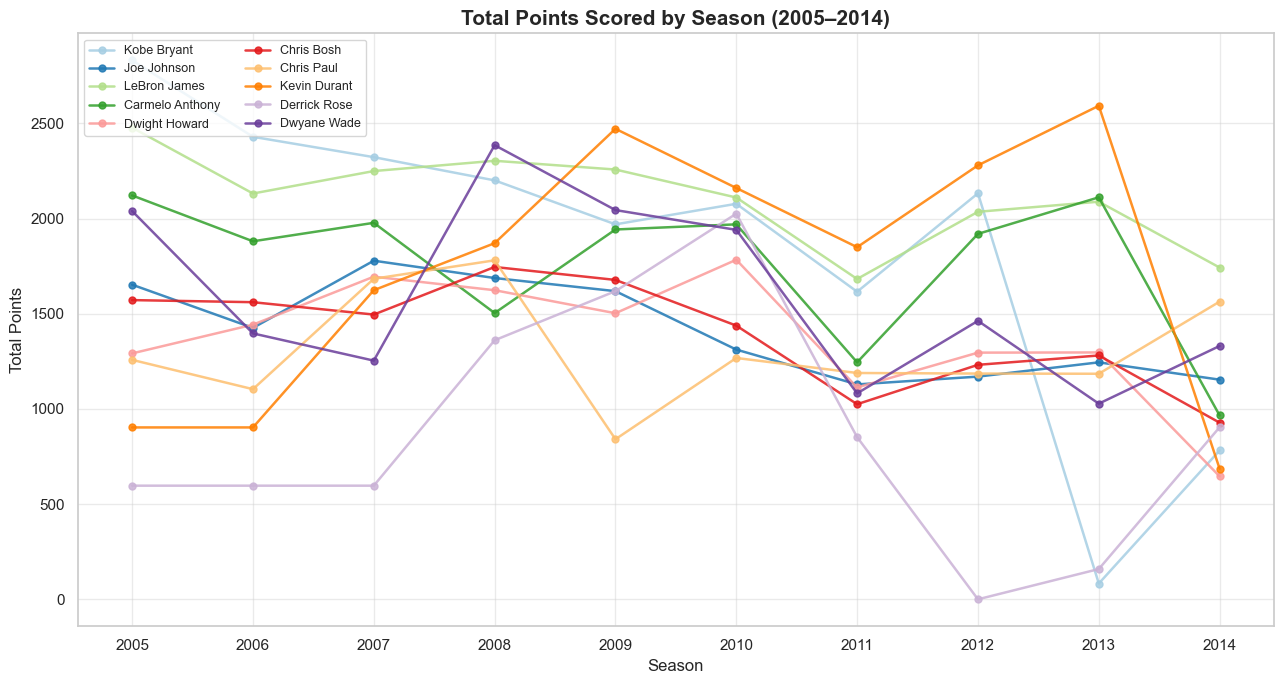

In [6]:
fig, ax = plt.subplots(figsize=(13, 7))

for player in players:
    pdf = df[df['player'] == player]
    ax.plot(pdf['season'], pdf['points'], marker='o', linewidth=1.8,
            markersize=5, label=player, alpha=0.85)

ax.set_title('Total Points Scored by Season (2005–2014)')
ax.set_xlabel('Season')
ax.set_ylabel('Total Points')
ax.set_xticks(seasons)
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

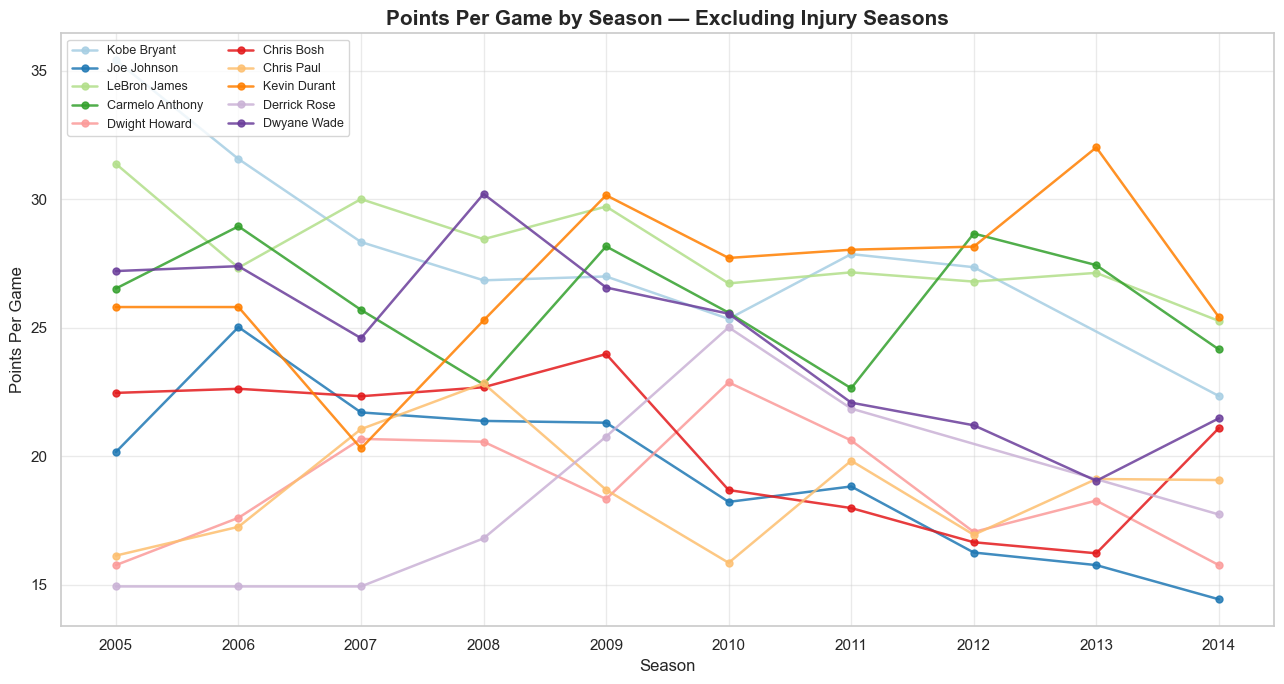

In [7]:
fig, ax = plt.subplots(figsize=(13, 7))

df_active = df[df['injury_season'] == False]

for player in players:
    pdf = df_active[df_active['player'] == player]
    ax.plot(pdf['season'], pdf['ppg'], marker='o', linewidth=1.8,
            markersize=5, label=player, alpha=0.85)

ax.set_title('Points Per Game by Season — Excluding Injury Seasons')
ax.set_xlabel('Season')
ax.set_ylabel('Points Per Game')
ax.set_xticks(seasons)
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

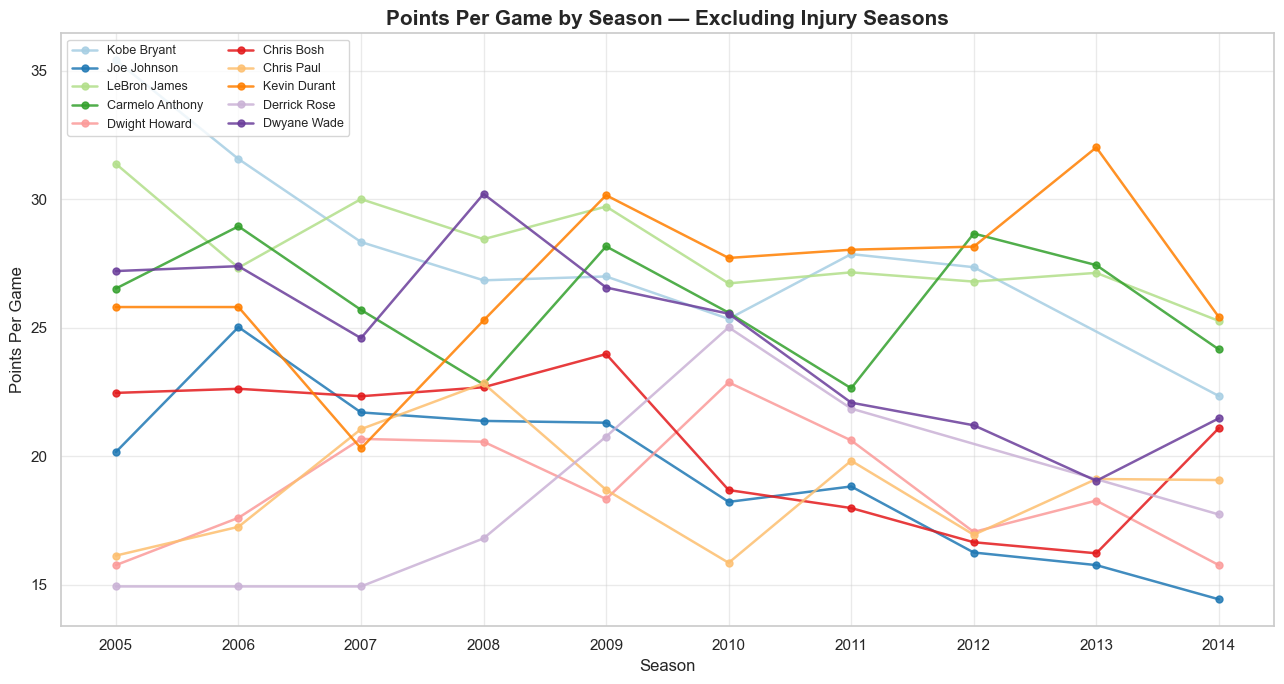

In [8]:
fig, ax = plt.subplots(figsize=(13, 7))

df_active = df[df['injury_season'] == False]

for player in players:
    pdf = df_active[df_active['player'] == player]
    ax.plot(pdf['season'], pdf['ppg'], marker='o', linewidth=1.8,
            markersize=5, label=player, alpha=0.85)

ax.set_title('Points Per Game by Season — Excluding Injury Seasons')
ax.set_xlabel('Season')
ax.set_ylabel('Points Per Game')
ax.set_xticks(seasons)
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


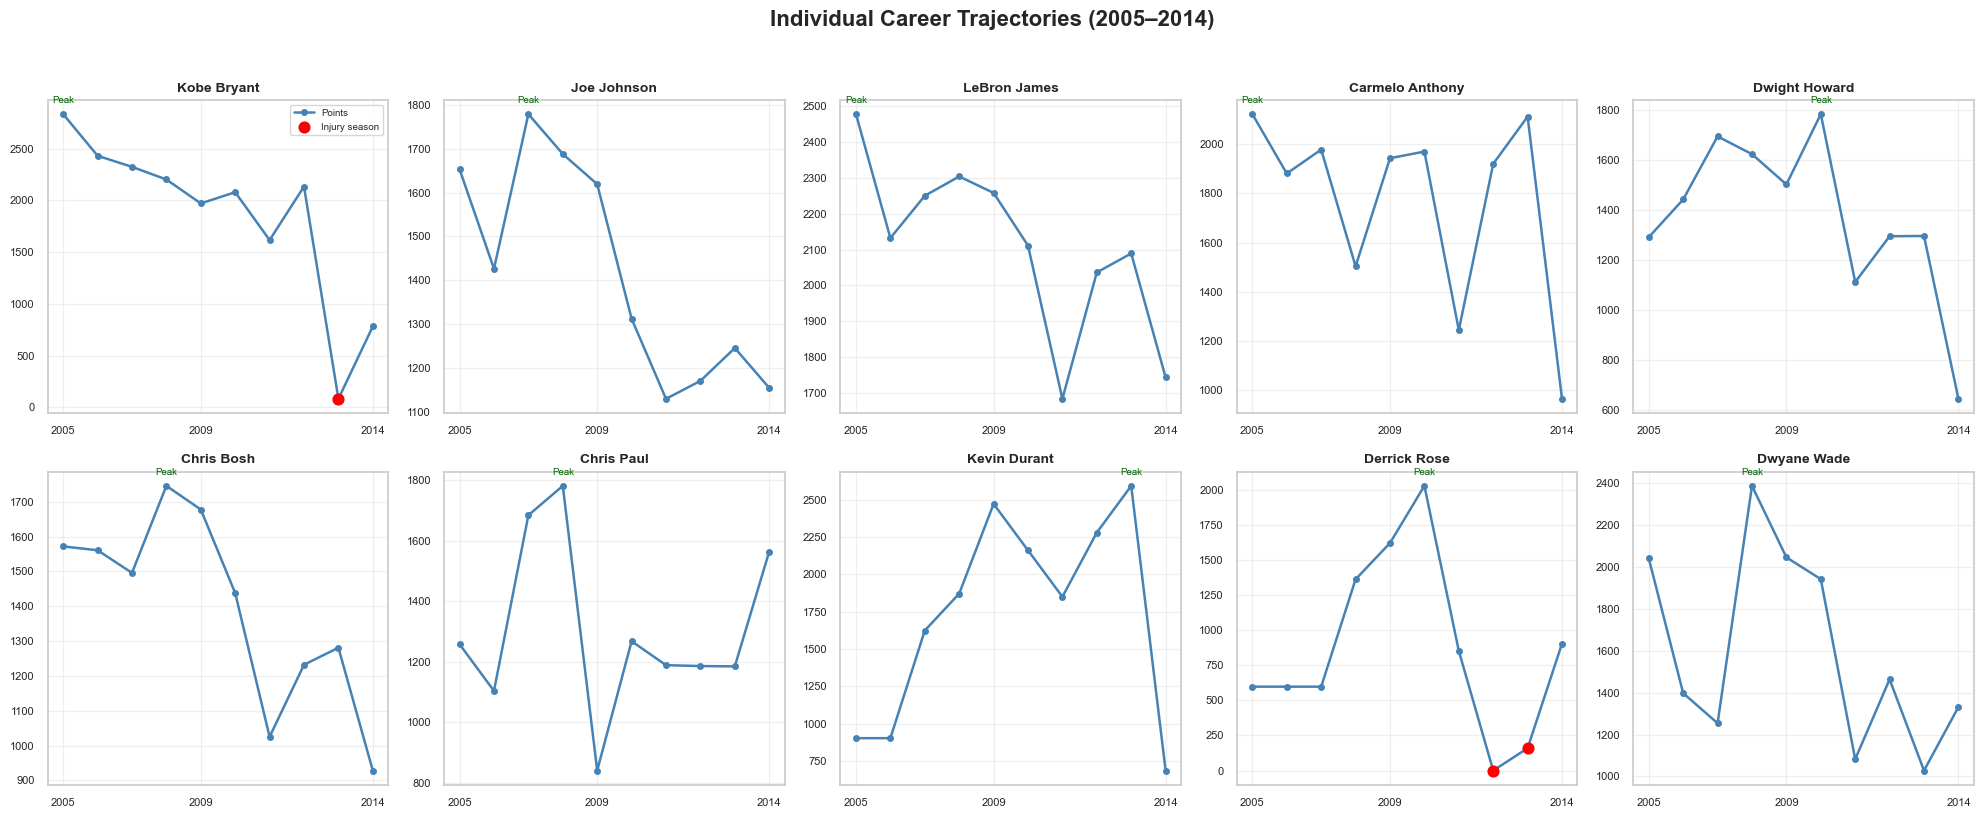

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=False)
axes = axes.flatten()

for idx, player in enumerate(players):
    pdf = df[df['player'] == player]
    ax  = axes[idx]

    # Points line
    ax.plot(pdf['season'], pdf['points'], marker='o', color='steelblue',
            linewidth=1.8, markersize=4, label='Points')

    # Highlight injury seasons in red
    inj = pdf[pdf['injury_season'] == True]
    ax.scatter(inj['season'], inj['points'], color='red',
               zorder=5, s=60, label='Injury season')

    # Peak season marker
    peak = pdf.loc[pdf['points'].idxmax()]
    ax.annotate('Peak', xy=(peak['season'], peak['points']),
                xytext=(0, 8), textcoords='offset points',
                fontsize=7, color='darkgreen', ha='center')

    ax.set_title(player, fontsize=10, fontweight='bold')
    ax.set_xticks([2005, 2009, 2014])
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.3)

    if idx == 0:
        ax.legend(fontsize=7)

fig.suptitle('Individual Career Trajectories (2005–2014)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



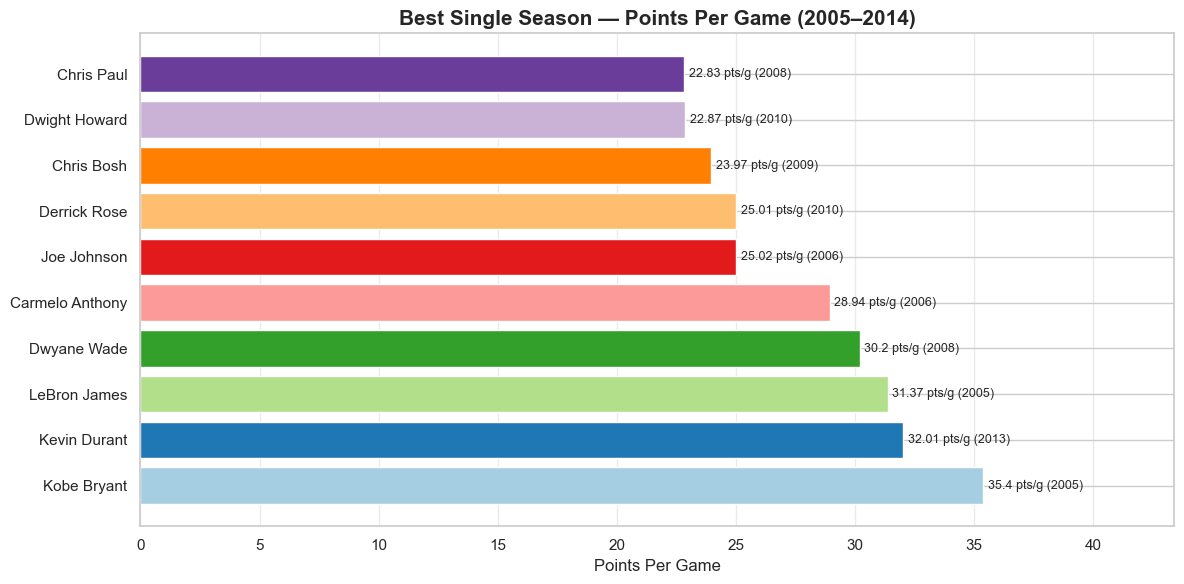

In [ ]:
# Best season per player by PPG (min 50 games)
peak_seasons = (
    df[df['games'] >= 50]
    .loc[df[df['games'] >= 50].groupby('player')['ppg'].idxmax()]
    [['player', 'season', 'points', 'ppg', 'fg_pct', 'games']]
    .sort_values('ppg', ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(peak_seasons['player'], peak_seasons['ppg'],
               color=sns.color_palette('Paired', len(players)))

for bar, (_, row) in zip(bars, peak_seasons.iterrows()):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{row['ppg']} pts/g ({int(row['season'])})",
            va='center', fontsize=9)

ax.set_title('Best Single Season — Points Per Game (2005–2014)')
ax.set_xlabel('Points Per Game')
ax.set_xlim(0, max(peak_seasons['ppg']) + 8)
ax.grid(True, axis='x', alpha=0.4)
plt.tight_layout()
plt.show()



In [11]:
summary = (
    df[df['injury_season'] == False]
    .groupby('player')
    .agg(
        total_points   = ('points',  'sum'),
        avg_ppg        = ('ppg',     'mean'),
        avg_fg_pct     = ('fg_pct',  'mean'),
        avg_minutes    = ('minutes', 'mean'),
        peak_points    = ('points',  'max'),
        seasons_played = ('season',  'count')
    )
    .round(2)
    .sort_values('avg_ppg', ascending=False)
    .reset_index()
)

print('Career Summary (excluding injury seasons):')
summary

Career Summary (excluding injury seasons):


,player,total_points,avg_ppg,avg_fg_pct,avg_minutes,peak_points,seasons_played
0,Kobe Bryant,18365,28.00,44.58,2737.22,2832,9
1,LeBron James,21084,27.99,50.93,2925.90,2478,10
2,Kevin Durant,17343,26.86,48.08,2414.00,2593,10
3,Carmelo Anthony,17641,26.06,45.80,2466.30,2122,10
4,Dwyane Wade,15967,24.53,49.53,2320.20,2386,10
5,Chris Bosh,13957,20.47,49.95,2463.10,1746,10
6,Joe Johnson,14175,19.30,44.60,2774.10,1779,10
7,Dwight Howard,13693,18.75,58.45,2614.20,1784,10
8,Chris Paul,13060,18.67,47.25,2530.50,1781,10
9,Derrick Rose,8553,18.37,46.00,1913.25,2026,8
